In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from numpy.fft import rfft, rfftfreq


In [ ]:
CLUSTER_TYPE = 'Lattice' # 'Lattice' or 'OffLattice' or 'Hybrid'
CLUSTER_SIZE = '1M' # '1M' or '10M'
SEED = 0
PATH = f'../results/analysis_clusters/{CLUSTER_TYPE}/{CLUSTER_SIZE}/{SEED}.npz'

plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 12


In [ ]:
try:
    with np.load(PATH, allow_pickle=True) as data:
        print(f"Loaded data from {PATH}, keys: {list(data.keys())}")

        coords = data['positions']

        if 'meta' in data:
            meta = data['meta']  # Assuming meta is stored as a dict
            print("Metadata:")
            print(meta)
    if coords.shape[0] == 2 and coords.shape[1] > 2:
        coords = coords.T  # Transpose if needed

    N = len(coords)
    
except FileNotFoundError:
    print(f"File not found: {PATH}")
    coords = None

if coords is not None:
    com = coords[0]
    coords_centered = coords - com
    t = np.arange(1, N+1)

Loaded data from ../results/analysis_clusters/Lattice/1M/0.npz, keys: ['positions', 'meta']
Metadata:
{'model': 'lattice', 'num_particles': 1000000, 'seed': 0, 'actual_particles': 1000000}
Number of particles in cluster: 1000000


GROWTH RATE CALCULATION

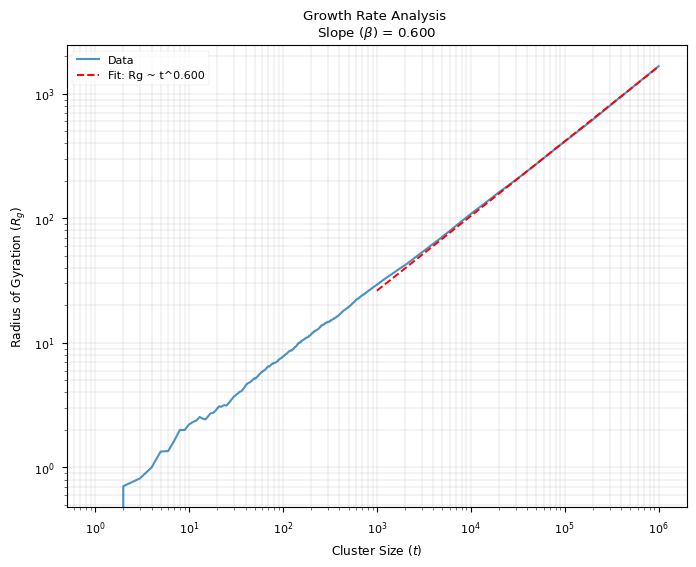

Growth exponent beta: 0.600158
Predicted dimension D = 1/beta: 1.666227


In [11]:
if coords is not None:
    r_sq = np.sum(coords_centered**2, axis=1)

    # calculate cumulative Radius of Gyration
    # rg(t) = sqrt(sum(r_i^2) / t)
    cumsum_r_sq = np.cumsum(r_sq)
    Rg = np.sqrt(cumsum_r_sq / t)
    fit_start_idx = 1000
    log_t = np.log(t[fit_start_idx:])
    log_Rg = np.log(Rg[fit_start_idx:])
    slope, intercept, r_value, p_value, std_err = linregress(log_t, log_Rg)
    beta = slope
    
    #Plotting
    plt.figure()
    plt.loglog(t, Rg, label='Data', linewidth=1.5, alpha=0.8)
    fit_line = np.exp(intercept + slope * log_t)
    plt.loglog(t[fit_start_idx:], fit_line, 'r--', label=f'Fit: Rg ~ t^{beta:.3f}')
    plt.xlabel('Cluster Size ($t$)')
    plt.ylabel('Radius of Gyration ($R_g$)')
    plt.title(f'Growth Rate Analysis \nSlope ($\\beta$) = {beta:.3f}')
    plt.legend()
    plt.grid(True, which="both", ls="-", linewidth=0.2)
    plt.show()
    print(f"Growth exponent beta: {beta:.6f}")
    print(f"Predicted dimension D = 1/beta: {1/beta:.6f}")

Minkowski Dimension (box-counting)

Calculating box counts...
Box-counting dimension D: 1.580650
Discrepancy from predicted D=1/beta: 0.085576


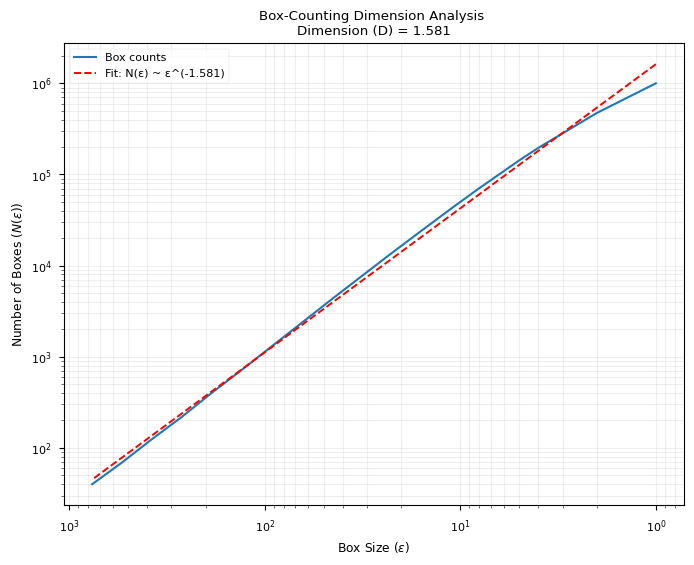

In [ ]:
if coords is not None:
    #define box sizes
    max_box_size = int(np.max(np.abs(coords_centered))) + 1
    scales = np.logspace(2, np.log2(max_box_size/4), num=20, base=2, dtype=int)
    scales = np.unique(scales)
    counts = []

    #calculation
    print("Calculating box counts...")
    for eps in scales:
        if eps<1:
            continue

        #map particles to integer grid coords
        grid_coords = np.floor(coords_centered / eps).astype(int)
        #get unique boxes occupied
        unique_boxes = np.unique(grid_coords, axis=0)
        counts.append(len(unique_boxes))

    #fitting to model N(eps) ~ eps^-D ie ln(N) ~ -D ln(eps)
    log_eps = np.log(scales)
    log_N = np.log(counts)
    slope, intercept, r_value, p_value, std_err = linregress(log_eps, log_N)
    D = -slope

    #Plotting
    plt.figure()
    plt.loglog(scales, counts, label='Box counts', linewidth=1.5)
    fit_line = np.exp(intercept + slope * log_eps)
    plt.loglog(scales, fit_line, 'r--', label=f'Fit: N(ε) ~ ε^(-{D:.3f})')
    plt.xlabel('Box Size ($\epsilon$)')
    plt.ylabel('Number of Boxes ($N(\\epsilon)$)')
    plt.title(f'Box-Counting Dimension Analysis \nDimension (D) = {D:.3f}')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.gca().invert_xaxis()  # large boxes on left, small boxes on right
    plt.show
    print(f"Box-counting dimension D: {D:.6f}")
    print(f"Discrepancy from predicted D=1/beta: {abs(D - 1/beta):.6f}")


Optimised Dimension Calculation

Calculating box counts for 20 scales...


/var/folders/4t/j6s0_pjn51gcp0q2x317m5n40000gn/T/ipykernel_63544/2835665864.py:42: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo" (-> marker='o'). The keyword argument will take precedence.
  plt.loglog(scales, counts, 'bo', label='Box counts', linewidth=0, marker='o', alpha=0.6)


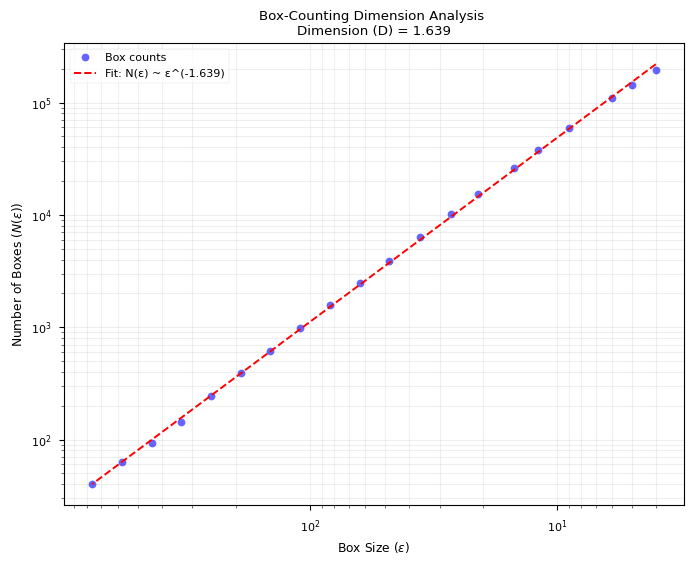

Box-counting dimension D: 1.639197
Discrepancy from predicted D=1/beta: 0.027029


In [24]:
if coords is not None:
    # --- CONFIGURATION ---
    max_box_size = int(np.max(np.abs(coords_centered))) + 1

    scales = np.logspace(2, np.log2(max_box_size/4), num=20, base=2, dtype=int)
    scales = np.unique(scales)
    
    counts = []

    # --- OPTIMIZED CALCULATION (1D Flattening) ---
    print(f"Calculating box counts for {len(scales)} scales...")
    
    # 1. Define a multiplier larger than the cluster width
    # This ensures (x, y) maps to a unique integer without collision
    # Cluster spans roughly -R to +R, so width is 2*R. 
    # We add a safety margin.
    Y_MULTIPLIER = int(max_box_size * 2 + 10000)

    for eps in scales:
        if eps < 1: continue

        # shift coordinates by +max_box_size to ensure all x,y are positive
        grid_x = np.floor((coords_centered[:, 0] + max_box_size) / eps).astype(np.int64)
        grid_y = np.floor((coords_centered[:, 1] + max_box_size) / eps).astype(np.int64)

        # flatten coords
        grid_hash = grid_x + (grid_y * Y_MULTIPLIER)
        
        # count unique integers
        unique_count = len(np.unique(grid_hash))
        counts.append(unique_count)

    # --- FITTING ---
    log_eps = np.log(scales)
    log_N = np.log(counts)
    
    slope, intercept, r_value, p_value, std_err = linregress(log_eps, log_N)
    D = -slope

    # --- PLOTTING ---
    plt.figure()
    plt.loglog(scales, counts, 'bo', label='Box counts', linewidth=0, marker='o', alpha=0.6)
    
    fit_line = np.exp(intercept + slope * log_eps)
    plt.loglog(scales, fit_line, 'r--', label=f'Fit: N(ε) ~ ε^(-{D:.3f})')
    
    plt.xlabel('Box Size ($\epsilon$)')
    plt.ylabel('Number of Boxes ($N(\\epsilon)$)')
    plt.title(f'Box-Counting Dimension Analysis \nDimension (D) = {D:.3f}')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.gca().invert_xaxis()
    plt.show()

    print(f"Box-counting dimension D: {D:.6f}")
    if 'beta' in locals():
        print(f"Discrepancy from predicted D=1/beta: {abs(D - 1/beta):.6f}")

Anistotropy Analysis

Calculating angular growth exponents...


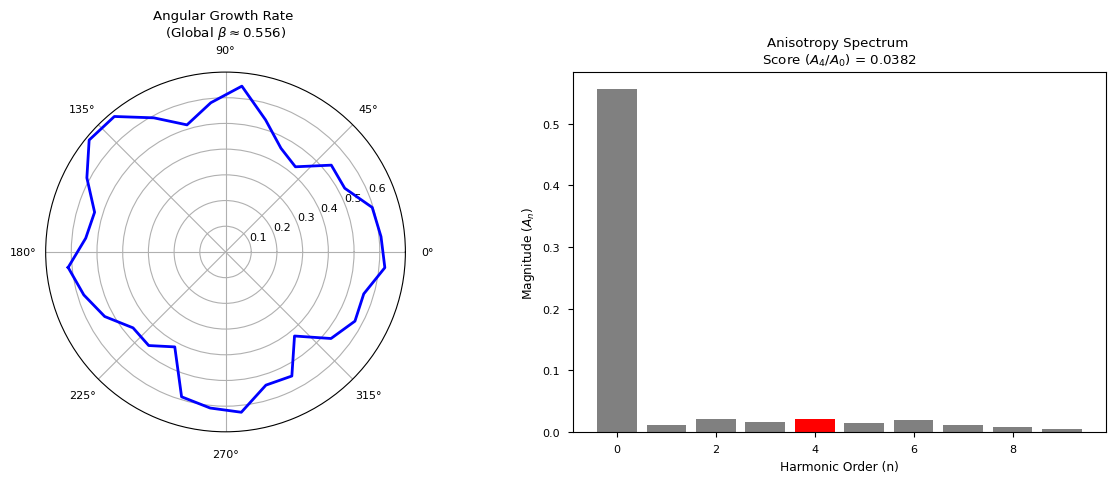

Average growth rate (A0): 0.555825
4-fold Anisotropy (A4): 0.021256


In [ ]:
#set-up
num_bins = 32 # 1 degree per bin
bin_edges = np.linspace(-np.pi, np.pi, num_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:]) #needed for plotting

# calculate angles:
angles = np.arctan2(coords_centered[:,1], coords_centered[:,0])

beta_thetas = []

print('Calculating angular growth exponents...')

for i in range(num_bins):
    #select particles in this angular bin
    in_bin = (angles >= bin_edges[i]) & (angles < bin_edges[i+1])
    coords_bin = coords_centered[in_bin]

    arrival_times = t[in_bin]
    N_bin = coords_bin.shape[0]
    

    if N_bin < 100:
        beta_thetas.append(np.nan) #not enough data
        continue

    #calculate Rg(t) for this bin
    r_sq_bin = np.sum(coords_bin**2, axis=1)
    cumsum_r_sq_bin = np.cumsum(r_sq_bin)
    local_count = np.arange(1, N_bin + 1)
    Rg_bin = np.sqrt(cumsum_r_sq_bin / local_count)

    #fit to get beta
    fit_start_idx = 100

    log_t_global = np.log(arrival_times[fit_start_idx:])
    log_Rg_bin = np.log(Rg_bin[fit_start_idx:])
    slope, intercept, r_value, p_value, std_err = linregress(log_t_global, log_Rg_bin)
    beta_thetas.append(slope)

#cleaning
beta_array = np.array(beta_thetas)
valid = ~np.isnan(beta_array)

#interpolation
if np.sum(valid) > 10:
    beta_cleaned = np.interp(
        np.arange(num_bins),
        np.arange(num_bins)[valid],
        beta_array[valid]
    )
else:
    beta_cleaned = np.full(num_bins, np.nan)

# perform FFT
coefs = np.fft.rfft(beta_cleaned)
magnitudes = np.abs(coefs) / num_bins

# metrics
A0 = magnitudes[0]  # DC component (average growth rate)
A4 = magnitudes[4]  # 4-fold symmetry component
score = A4 / A0 if A0 != 0 else np.nan

#plotting
fig = plt.figure(figsize=(12, 5))

theta_plot = np.concatenate((bin_centers, [bin_centers[0] + 2*np.pi]))
beta_plot = np.concatenate((beta_cleaned, [beta_cleaned[0]]))

ax1 = fig.add_subplot(1, 2, 1, projection='polar')
ax1.plot(theta_plot, beta_plot, label=r'$\beta(\theta)$', color='b', linewidth=2)
ax1.set_title(f'Angular Growth Rate \n(Global $\\beta \\approx {A0:.3f}$)')
ax1.grid(True)
ax1.set_ylim(bottom=0) 

ax2 = fig.add_subplot(1, 2, 2)
freqs = np.arange(len(magnitudes))
ax2.bar(freqs[:10], magnitudes[:10], color='gray') 
ax2.patches[4].set_facecolor('r') 
ax2.set_xlabel('Harmonic Order (n)')
ax2.set_ylabel('Magnitude ($A_n$)')
ax2.set_title(f'Anisotropy Spectrum \nScore ($A_4/A_0$) = {score:.4f}')

plt.tight_layout()
plt.show()

print(f"Average growth rate (A0): {A0:.6f}")
print(f"4-fold Anisotropy (A4): {A4:.6f}")


AttributeError: 'Figure' object has no attribute 'set_xlabel'

<Figure size 1200x500 with 0 Axes>